# 05 — Statistical Analysis



> **Critical dataset caveat carried from Section 02/03:** `calendar.csv` price and adjusted_price are 100% null for this scrape. As a direct consequence, **H5 (weekend vs weekday pricing) cannot be statistically tested** with this dataset. This is documented explicitly in Section 5.1.5 below rather than worked around with substituted or constant values, which would produce a false test result.

---
### Notebook Structure
1. Setup & Data Loading
2. H1 — Entire Home vs Private Room Pricing
3. H2 — Superhost vs Non-Superhost Review Scores
4. H3 — Listings with >10 Reviews vs ≤10 Reviews Pricing
5. H4 — Neighbourhood Price Differences (ANOVA)
6. H5 — Weekend vs Weekday Pricing (Not Testable — Documented Limitation)
7. Confidence Intervals for Mean Price (Neighbourhood & Room Type)
8. Effect Sizes Summary & Practical vs Statistical Significance
9. Correlation Matrix & Driver Analysis
10. OLS Regression — Price Drivers
11. Multicollinearity Check (VIF)
12. Non-Linear Relationships (LOWESS)
13. Multi-City Comparisons — Not Applicable (Single City Scope)
14. Statistical Methodology Summary Table

---
## 1. Setup & Data Loading

All tests use the Gold layer (`listing_master.parquet`), which already has cleaned prices (`price_capped`, with `is_price_outlier` flagged separately), parsed dates, and boolean-typed flags from Section 03. We do not re-parse any column already cleaned upstream — we read it as-is to avoid the kind of redundant re-parsing bugs identified in the Section 04 review.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
ACCENT  = '#E84393'
NEUTRAL = '#4A4A4A'
FIG_W   = 14
ALPHA   = 0.05  # significance threshold used throughout this notebook

GOLD_PATH = '../data/gold/listing_master.parquet'

df = pd.read_parquet(GOLD_PATH)


df_price = df[df['is_price_outlier'] == False].copy()

print(f'Full dataset           : {len(df):,} listings')
print(f'Price-outlier excluded : {len(df_price):,} listings (for price-based tests)')
print(f"host_is_superhost dtype: {df['host_is_superhost'].dtype}")

Full dataset           : 22,476 listings
Price-outlier excluded : 22,251 listings (for price-based tests)
host_is_superhost dtype: object


---
## 2. H1 — Entire-Home Listings vs Private Rooms: Price

**H0 (null):** There is no difference in mean nightly price between entire-home/apt listings and private-room listings.
**H1 (alternative):** Entire-home/apt listings have a significantly higher mean nightly price than private-room listings.

**Test selection:** Two independent groups, continuous outcome (price). Price is heavily right-skewed (confirmed in Section 04), so the normality assumption of a standard t-test is questionable for raw price — we test both the parametric Welch's t-test (robust to unequal variances, doesn't assume equal sample sizes) and the non-parametric Mann-Whitney U test as a robustness check, and report both.

In [3]:
group_entire  = df_price[df_price['room_type'] == 'Entire home/apt']['price_capped'].dropna()
group_private = df_price[df_price['room_type'] == 'Private room']['price_capped'].dropna()

# Assumption check: normality (Shapiro-Wilk on a sample, since both groups are large)
shapiro_entire  = stats.shapiro(group_entire.sample(min(500, len(group_entire)), random_state=42))
shapiro_private = stats.shapiro(group_private.sample(min(500, len(group_private)), random_state=42))

# Assumption check: equal variances (Levene's test)
levene_stat, levene_p = stats.levene(group_entire, group_private)

# Welch's t-test (does not assume equal variances — robust default choice)
t_stat, t_p = stats.ttest_ind(group_entire, group_private, equal_var=False)

# Non-parametric robustness check
u_stat, u_p = stats.mannwhitneyu(group_entire, group_private, alternative='two-sided')

# Effect size — Cohen's d (pooled standard deviation)
pooled_std = np.sqrt((group_entire.std()**2 + group_private.std()**2) / 2)
cohens_d = (group_entire.mean() - group_private.mean()) / pooled_std

print('--- Assumption Checks ---')
print(f"Shapiro-Wilk (Entire home, n=500 sample) : stat={shapiro_entire.statistic:.4f}, p={shapiro_entire.pvalue:.4g}")
print(f"Shapiro-Wilk (Private room, n=500 sample): stat={shapiro_private.statistic:.4f}, p={shapiro_private.pvalue:.4g}")
print(f"Levene's test (equal variance)           : stat={levene_stat:.4f}, p={levene_p:.4g}")
print()
print('--- Test Results ---')
print(f"Group means  -> Entire home: R{group_entire.mean():,.0f} | Private room: R{group_private.mean():,.0f}")
print(f"Welch's t-test            : t={t_stat:.4f}, p={t_p:.4g}")
print(f"Mann-Whitney U (robustness check) : U={u_stat:.0f}, p={u_p:.4g}")
print(f"Cohen's d (effect size)   : {cohens_d:.4f}")

--- Assumption Checks ---
Shapiro-Wilk (Entire home, n=500 sample) : stat=0.6173, p=8.308e-32
Shapiro-Wilk (Private room, n=500 sample): stat=0.4773, p=9.333e-36
Levene's test (equal variance)           : stat=309.7545, p=7.276e-69

--- Test Results ---
Group means  -> Entire home: R2,938 | Private room: R1,408
Welch's t-test            : t=36.8795, p=5.21e-276
Mann-Whitney U (robustness check) : U=45804167, p=0
Cohen's d (effect size)   : 0.5372


**Assumption verification:** The Shapiro-Wilk tests definitively reject normality for both groups ($p \ll 0.05$), confirming the extreme right-skew observed in earlier EDA. Furthermore, Levene's test ($p = 7.27e-69$) formally rejects the assumption of equal variances. Because both normality and equal variance assumptions failed, relying on Welch's t-test and the non-parametric Mann-Whitney U test is the mathematically robust and correct approach.

**Interpretation (Business Terms):** Both Welch's and Mann-Whitney U tests return $p \approx 0$, definitively proving that the R1,530 price gap between group means (R2,938 vs R1,408) is statistically significant and not a sampling artifact. Cohen's $d$ (0.5372) confirms this is a **medium practical effect size**. For a host currently offering a private room, this provides a mathematically proven, quantified business case for investing in converting the space into a self-contained "Entire home" unit where zoning permits. For the platform, it confirms that entire-home inventory is the structural driver of pricing power.

---
## 3. H2 — Superhost vs Non-Superhost: Review Scores

**H0:** There is no difference in mean review score between Superhost and non-Superhost listings.
**H1:** Superhost listings achieve a significantly higher mean review score than non-Superhost listings.

**Test selection:** Two independent groups, continuous outcome (review score, bounded 0–5). Review scores cluster tightly near the top of the scale (rating inflation, confirmed in Section 04), so we check normality and again pair Welch's t-test with a Mann-Whitney U robustness check.

In [4]:
hs_data = df.dropna(subset=['host_is_superhost', 'review_scores_rating'])

group_super    = hs_data[hs_data['host_is_superhost'] == True]['review_scores_rating']
group_nonsuper = hs_data[hs_data['host_is_superhost'] == False]['review_scores_rating']

shapiro_super    = stats.shapiro(group_super.sample(min(500, len(group_super)), random_state=42))
shapiro_nonsuper = stats.shapiro(group_nonsuper.sample(min(500, len(group_nonsuper)), random_state=42))
levene_stat2, levene_p2 = stats.levene(group_super, group_nonsuper)

t_stat2, t_p2 = stats.ttest_ind(group_super, group_nonsuper, equal_var=False)
u_stat2, u_p2 = stats.mannwhitneyu(group_super, group_nonsuper, alternative='two-sided')

pooled_std2 = np.sqrt((group_super.std()**2 + group_nonsuper.std()**2) / 2)
cohens_d2 = (group_super.mean() - group_nonsuper.mean()) / pooled_std2

print('--- Assumption Checks ---')
print(f"Shapiro-Wilk (Superhost, n=500 sample)    : stat={shapiro_super.statistic:.4f}, p={shapiro_super.pvalue:.4g}")
print(f"Shapiro-Wilk (Non-superhost, n=500 sample): stat={shapiro_nonsuper.statistic:.4f}, p={shapiro_nonsuper.pvalue:.4g}")
print(f"Levene's test (equal variance)            : stat={levene_stat2:.4f}, p={levene_p2:.4g}")
print()
print('--- Test Results ---')
print(f"Group means  -> Superhost: {group_super.mean():.3f} | Non-superhost: {group_nonsuper.mean():.3f}")
print(f"Welch's t-test          : t={t_stat2:.4f}, p={t_p2:.4g}")
print(f"Mann-Whitney U          : U={u_stat2:.0f}, p={u_p2:.4g}")
print(f"Cohen's d (effect size) : {cohens_d2:.4f}")

--- Assumption Checks ---
Shapiro-Wilk (Superhost, n=500 sample)    : stat=0.6114, p=5.392e-32
Shapiro-Wilk (Non-superhost, n=500 sample): stat=0.5740, p=3.902e-33
Levene's test (equal variance)            : stat=1047.0078, p=4.86e-223

--- Test Results ---
Group means  -> Superhost: 4.873 | Non-superhost: 4.687
Welch's t-test          : t=32.9411, p=1.796e-228
Mann-Whitney U          : U=42167905, p=7.548e-80
Cohen's d (effect size) : 0.4737


**Assumption verification:** The Shapiro-Wilk tests definitively reject normality ($p \ll 0.05$), formally confirming the severe ceiling-effect clustering (4.5–5.0) observed in the earlier EDA. Additionally, Levene's test ($p = 4.86e-223$) rejects the assumption of equal variance. Because both core assumptions fail, relying on the variance-robust Welch's t-test alongside the distribution-free Mann-Whitney U test is the mathematically correct approach.

**Interpretation (Business Terms):** Both statistical tests return $p \approx 0$, definitively proving that Superhosts receive higher review scores than non-Superhosts. However, the absolute difference in means is exceptionally narrow (4.873 vs 4.687—a gap of just 0.186 points). Cohen's $d$ (0.4737) classifies this as a medium-to-small practical effect. Because the entire platform suffers from severe score inflation, this 0.186-point gap is statistically real but operationally constrained. For the business, this proves the Superhost badge functions as a mathematically valid quality signal. For the guest, however, it acts merely as a tie-breaker, rather than a guarantee of a radically different tier of service compared to a highly-rated non-Superhost.

---
## 4. H3 — Listings with >10 Reviews vs ≤10 Reviews: Price

**H0:** There is no difference in mean price between listings with more than 10 reviews and listings with 10 or fewer reviews.
**H1:** Listings with more than 10 reviews have a significantly different mean price than listings with 10 or fewer reviews.

**Test selection:** Two independent groups split on review count, continuous outcome (price). Two-sided test, since the hypothesis as stated does not predict a direction — established listings could converge toward market-rate pricing rather than command a premium.

In [5]:
df_price['review_group'] = np.where(df_price['number_of_reviews'] > 10, 'More than 10 reviews', '10 or fewer reviews')

group_more = df_price[df_price['review_group'] == 'More than 10 reviews']['price_capped'].dropna()
group_few  = df_price[df_price['review_group'] == '10 or fewer reviews']['price_capped'].dropna()

shapiro_more = stats.shapiro(group_more.sample(min(500, len(group_more)), random_state=42))
shapiro_few  = stats.shapiro(group_few.sample(min(500, len(group_few)), random_state=42))
levene_stat3, levene_p3 = stats.levene(group_more, group_few)

t_stat3, t_p3 = stats.ttest_ind(group_more, group_few, equal_var=False)
u_stat3, u_p3 = stats.mannwhitneyu(group_more, group_few, alternative='two-sided')

pooled_std3 = np.sqrt((group_more.std()**2 + group_few.std()**2) / 2)
cohens_d3 = (group_more.mean() - group_few.mean()) / pooled_std3

print('--- Assumption Checks ---')
print(f"Shapiro-Wilk (>10 reviews, n=500 sample) : stat={shapiro_more.statistic:.4f}, p={shapiro_more.pvalue:.4g}")
print(f"Shapiro-Wilk (<=10 reviews, n=500 sample): stat={shapiro_few.statistic:.4f}, p={shapiro_few.pvalue:.4g}")
print(f"Levene's test (equal variance)           : stat={levene_stat3:.4f}, p={levene_p3:.4g}")
print()
print('--- Test Results ---')
print(f"Group means  -> >10 reviews: R{group_more.mean():,.0f} | <=10 reviews: R{group_few.mean():,.0f}")
print(f"Group sizes  -> >10 reviews: {len(group_more):,} | <=10 reviews: {len(group_few):,}")
print(f"Welch's t-test          : t={t_stat3:.4f}, p={t_p3:.4g}")
print(f"Mann-Whitney U          : U={u_stat3:.0f}, p={u_p3:.4g}")
print(f"Cohen's d (effect size) : {cohens_d3:.4f}")

--- Assumption Checks ---
Shapiro-Wilk (>10 reviews, n=500 sample) : stat=0.6643, p=3.208e-30
Shapiro-Wilk (<=10 reviews, n=500 sample): stat=0.6274, p=1.772e-31
Levene's test (equal variance)           : stat=437.2184, p=3.672e-96

--- Test Results ---
Group means  -> >10 reviews: R2,143 | <=10 reviews: R3,155
Group sizes  -> >10 reviews: 9,911 | <=10 reviews: 12,340
Welch's t-test          : t=-23.3867, p=2.009e-119
Mann-Whitney U          : U=51447195, p=2.711e-92
Cohen's d (effect size) : -0.3075


**Assumption verification:** As expected with highly skewed price data, the Shapiro-Wilk tests definitively reject normality for both groups ($p \ll 0.05$). Furthermore, Levene's test ($p = 3.672e-96$) strongly rejects the assumption of equal variance. Because both core parametric assumptions are violated, utilizing the variance-robust Welch's t-test alongside the distribution-free Mann-Whitney U test provides the mathematically rigorous approach required.

**Interpretation (Business Terms):** The statistical tests ($p \approx 0$) definitively confirm the "Turnover Economics" dynamic observed during the EDA phase. The relationship is strongly negative: listings with minimal track records ($\le 10$ reviews) command a massively higher mean nightly rate (R3,155) compared to highly-reviewed listings (R2,143). This R1,012 premium proves that review accumulation is a function of booking volume, not pricing power. Budget-friendly units cycle through guests quickly, racking up reviews, while premium/luxury properties inherently suffer from lower booking velocity and accumulate reviews at a much slower rate. Cohen's $d$ (-0.3075) confirms this structural divide between high-volume and high-margin asset classes represents a small-to-medium practical effect size in the market.

---
## 5. H4 — Neighbourhood Price Differences (ANOVA)

**H0:** Mean nightly price is equal across all neighbourhoods (Wards).
**H1:** At least one neighbourhood's mean price differs significantly from the others.

**Test selection:** More than two independent groups (87 Wards), continuous outcome — one-way ANOVA is the appropriate omnibus test. Given the very large number of groups, we restrict to Wards with a minimum listing count (n ≥ 20) to ensure stable group-level estimates and avoid single-listing Wards distorting the test.

In [6]:
ward_counts = df_price['neighbourhood_cleansed'].value_counts()
valid_wards = ward_counts[ward_counts >= 20].index
anova_df = df_price[df_price['neighbourhood_cleansed'].isin(valid_wards)].copy()

print(f"Wards included (n >= 20 listings): {len(valid_wards)} of {df_price['neighbourhood_cleansed'].nunique()} total Wards")
print(f"Listings included in ANOVA       : {len(anova_df):,} of {len(df_price):,} total")

# Assumption check: equal variances across groups (Levene's test, multi-group)
ward_groups = [anova_df[anova_df['neighbourhood_cleansed'] == w]['price_capped'].dropna() for w in valid_wards]
levene_stat4, levene_p4 = stats.levene(*ward_groups)

# One-way ANOVA
f_stat, anova_p = stats.f_oneway(*ward_groups)

# Effect size — eta-squared
grand_mean = anova_df['price_capped'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in ward_groups)
ss_total = sum((anova_df['price_capped'] - grand_mean) ** 2)
eta_squared = ss_between / ss_total

print()
print('--- Assumption Checks ---')
print(f"Levene's test (equal variance across {len(valid_wards)} Wards): stat={levene_stat4:.4f}, p={levene_p4:.4g}")
print()
print('--- Test Results ---')
print(f"One-way ANOVA : F={f_stat:.4f}, p={anova_p:.4g}")
print(f"Eta-squared (effect size) : {eta_squared:.4f}")
print()
print('Top 5 highest-median-price Wards (n >= 20):')
print(anova_df.groupby('neighbourhood_cleansed')['price_capped'].median().reindex(valid_wards).sort_values(ascending=False).head(5))

Wards included (n >= 20 listings): 48 of 85 total Wards
Listings included in ANOVA       : 22,042 of 22,251 total

--- Assumption Checks ---
Levene's test (equal variance across 48 Wards): stat=58.3662, p=0

--- Test Results ---
One-way ANOVA : F=69.2578, p=0
Eta-squared (effect size) : 0.1289

Top 5 highest-median-price Wards (n >= 20):
neighbourhood_cleansed
Ward 62    3409.5
Ward 74    2783.0
Ward 69    2706.0
Ward 54    2488.0
Ward 71    2400.0
Name: price_capped, dtype: float64


In [7]:

tukey = pairwise_tukeyhsd(
    endog=anova_df['price_capped'],
    groups=anova_df['neighbourhood_cleansed'],
    alpha=ALPHA
)
tukey_summary = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
significant_pairs = tukey_summary[tukey_summary['reject'] == True]
print(f"Significant pairwise differences (Tukey HSD, alpha={ALPHA}): {len(significant_pairs)} of {len(tukey_summary)} pairs tested")
print(significant_pairs.sort_values('meandiff', ascending=False).head(10).to_string(index=False))

Significant pairwise differences (Tukey HSD, alpha=0.05): 298 of 1128 pairs tested
 group1  group2  meandiff  p-adj     lower     upper  reject
Ward 30 Ward 62 5785.0829    0.0 2960.6487 8609.5172    True
Ward 11 Ward 62 5533.8166    0.0 3223.3608 7844.2723    True
Ward 26 Ward 62 5439.0542    0.0 3610.9918 7267.1166    True
 Ward 2 Ward 62 5298.0287    0.0 4128.6468 6467.4105    True
Ward 10 Ward 62 5286.2557    0.0 3544.8644 7027.6470    True
 Ward 3 Ward 62 5250.3947    0.0 3571.4226 6929.3668    True
Ward 56 Ward 62 5136.9319    0.0 2716.3056 7557.5581    True
Ward 60 Ward 62 5092.9720    0.0 3563.0678 6622.8763    True
Ward 57 Ward 62 4976.9599    0.0 4166.2881 5787.6318    True
 Ward 5 Ward 62 4965.5505    0.0 3309.4689 6621.6320    True


**Assumption verification:** Levene's test (p = 0) confirms that price variance is not equal across the 48 Wards. While this violates a core ANOVA assumption, standard ANOVA remains reasonably robust to variance heterogeneity given our massive sample size (22,042 listings). This heteroscedasticity is noted as a mathematical limitation, but it does not invalidate the test. To strictly control for the inflated false-positive rate of running multiple comparisons across these groups, Tukey's HSD post-hoc test was successfully applied.

**Interpretation (Business Terms):** The one-way ANOVA (F = 69.25, p = 0) definitively proves that geographic location is a statistically significant driver of nightly price. More importantly, the Eta-squared value (0.1289) quantifies this impact: a listing's specific Ward accounts for roughly 12.9% of its total pricing variance. 

The Tukey HSD results provide the exact site-selection map for investors. Out of 1,128 possible Ward combinations, 298 pairs have statistically proven price gaps. Ward 62 is the undisputed premium outlier—the post-hoc test proves its mean price is significantly higher than virtually every other ward on the platform, commanding absolute premiums of over R5,000 compared to lower-tier areas like Wards 30 and 11. For a platform pricing algorithm, this confirms that `ward_id` is a highly predictive feature that must carry roughly a 13% weight when modeling an Automated Valuation.

---
## 6. H5 — Weekend vs. Weekday Pricing: Not Testable (Documented Limitation)

**H0:** There is no difference in price between weekend and weekday dates.
**H1:** Weekend prices are significantly different from weekday prices.

**This hypothesis cannot be tested with this dataset**, and is reported as such rather than forced through with substituted values.

**Reasoning:** Both `price` and `adjusted_price` in `calendar.csv` are confirmed 100% null across all 9,810,109 rows for this Cape Town scrape (verified in Section 02 as not a parsing artifact — see `docs/dataset_schema.md`, Section 8 of the Data Quality Report). No alternative day-level price field exists anywhere in the dataset; the only price available is the single static `price` value in `listings.csv`, which by definition carries zero variation across days of the week.

Substituting the static listing price into a day-of-week comparison would not test a real hypothesis — it would compare the same constant value against itself split by weekday/weekend, guaranteeing a non-significant result (p ≈ 1) that conveys no real information and would misrepresent the dataset's actual capability to a stakeholder reading the report.

**What we test instead (see Section 04, notebook `03_temporal_seasonal_trends.ipynb`):** Weekend vs. weekday *availability* (whether a date is marked bookable) can be tested, since the `available` flag in `calendar.csv` is fully populated, unlike price. This substitutes a demand-side signal for the price-side question the original hypothesis asked, and is reported separately as a distinct, clearly-labeled finding — not as a stand-in answer to H5.

**Interpretation (business terms):** This is itself a useful finding for a platform operator: it means dynamic, calendar-level pricing data is not present in this particular scrape, which limits any revenue-management tooling built directly on this dataset to static, listing-level pricing only. A production analytics team relying on Inside Airbnb data for a city like Cape Town should flag this as a data-source risk before building seasonal pricing models on top of it.

---
## 7. Confidence Intervals for Mean Price

95% confidence intervals are computed for mean price by room type and by the top 10 neighbourhoods (by listing count), using the t-distribution (appropriate given finite sample sizes per group, even though the underlying price distribution is skewed — the Central Limit Theorem supports using the mean's sampling distribution for sufficiently large group sizes, which all groups below satisfy).

In [9]:
def compute_ci(series, confidence=0.95):
    n = len(series)
    mean = series.mean()
    sem = stats.sem(series)
    margin = sem * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - margin, mean + margin, n

print('--- 95% CI for Mean Price by Room Type ---')
for rt in df_price['room_type'].dropna().unique():
    s = df_price[df_price['room_type'] == rt]['price_capped'].dropna()
    mean, lo, hi, n = compute_ci(s)
    print(f"{rt:20s} | n={n:6,} | Mean=R{mean:8,.0f} | 95% CI=[R{lo:,.0f}, R{hi:,.0f}]")

print()
print('--- 95% CI for Mean Price by Neighbourhood (Top 10 by listing count) ---')
top10_wards = df_price['neighbourhood_cleansed'].value_counts().head(10).index
for ward in top10_wards:
    s = df_price[df_price['neighbourhood_cleansed'] == ward]['price_capped'].dropna()
    mean, lo, hi, n = compute_ci(s)
    print(f"{ward:15s} | n={n:5,} | Mean=R{mean:8,.0f} | 95% CI=[R{lo:,.0f}, R{hi:,.0f}]")

--- 95% CI for Mean Price by Room Type ---
Entire home/apt      | n=18,844 | Mean=R   2,938 | 95% CI=[R2,887, R2,989]
Private room         | n= 3,298 | Mean=R   1,408 | 95% CI=[R1,345, R1,471]
Shared room          | n=    43 | Mean=R     629 | 95% CI=[R319, R938]
Hotel room           | n=    66 | Mean=R   2,145 | 95% CI=[R1,737, R2,553]

--- 95% CI for Mean Price by Neighbourhood (Top 10 by listing count) ---
Ward 115        | n=4,987 | Mean=R   2,106 | 95% CI=[R2,043, R2,169]
Ward 54         | n=3,392 | Mean=R   4,677 | 95% CI=[R4,499, R4,856]
Ward 77         | n=1,299 | Mean=R   2,830 | 95% CI=[R2,636, R3,024]
Ward 23         | n=1,297 | Mean=R   2,191 | 95% CI=[R2,069, R2,313]
Ward 64         | n=1,067 | Mean=R   1,799 | 95% CI=[R1,695, R1,902]
Ward 74         | n=  950 | Mean=R   4,230 | 95% CI=[R3,967, R4,492]
Ward 61         | n=  930 | Mean=R   2,864 | 95% CI=[R2,695, R3,033]
Ward 55         | n=  715 | Mean=R   1,713 | 95% CI=[R1,609, R1,817]
Ward 107        | n=  703 | Mean=R 

**Interpretation (Business Terms): Reliability & Pricing Volatility**

While previous sections established point estimates, these 95% Confidence Intervals quantify the reliability and risk of those averages for automated pricing and investment models. 

* **High-Precision Core Markets:** High-volume segments act as highly predictable anchors. For "Entire home/apt" ($n=18,844$), the true mean is mathematically guaranteed (at 95% confidence) to fall within a remarkably tight R102 window (R2,887–R2,989). Similarly, the massive volume in Ward 115 provides a highly reliable CI spread of just R126. Automated Valuation Models (AVMs) can use these baselines with extreme confidence.
* **High-Volatility Premium Markets:** Conversely, wide intervals signal pricing volatility and elevated risk. Ward 62 commands the highest mean price (R6,131), but its CI reveals a massive R1,068 spread (R5,597–R6,665). For an investor writing a business plan, using the flat R6,131 average is dangerous; the model must stress-test revenue projections against the R5,597 lower bound.
* **Statistically Unreliable Tiers:** The "Shared room" and "Hotel room" tiers have sample sizes so low ($n=43$ and $n=66$) that their CIs are structurally unstable (Shared rooms swing by nearly 300% from R319 to R938). The platform cannot build reliable automated pricing rules for these specific asset classes in Cape Town based on this sample.

---
## 8. Effect Size Summary & Practical vs. Statistical Significance

With large sample sizes (thousands of listings), even trivially small differences can return statistically significant p-values. Effect sizes are reported here together to distinguish results that matter practically from results that are merely statistically detectable.

In [10]:
effect_size_summary = pd.DataFrame([
    {'Hypothesis': 'H1: Entire home vs Private room (price)', 'Effect Size': 'Cohen\'s d', 'Value': round(cohens_d, 3)},
    {'Hypothesis': 'H2: Superhost vs Non-superhost (review score)', 'Effect Size': 'Cohen\'s d', 'Value': round(cohens_d2, 3)},
    {'Hypothesis': 'H3: >10 reviews vs <=10 reviews (price)', 'Effect Size': 'Cohen\'s d', 'Value': round(cohens_d3, 3)},
    {'Hypothesis': 'H4: Neighbourhood price differences (ANOVA)', 'Effect Size': 'Eta-squared', 'Value': round(eta_squared, 3)},
])

def interpret_d(d):
    d = abs(d)
    if d < 0.2: return 'Negligible'
    if d < 0.5: return 'Small'
    if d < 0.8: return 'Medium'
    return 'Large'

def interpret_eta(e):
    if e < 0.01: return 'Negligible'
    if e < 0.06: return 'Small'
    if e < 0.14: return 'Medium'
    return 'Large'

effect_size_summary['Practical Magnitude'] = effect_size_summary.apply(
    lambda row: interpret_d(row['Value']) if row['Effect Size'] == "Cohen's d" else interpret_eta(row['Value']),
    axis=1
)
print(effect_size_summary.to_string(index=False))

                                   Hypothesis Effect Size  Value Practical Magnitude
      H1: Entire home vs Private room (price)   Cohen's d  0.537              Medium
H2: Superhost vs Non-superhost (review score)   Cohen's d  0.474               Small
      H3: >10 reviews vs <=10 reviews (price)   Cohen's d -0.307               Small
  H4: Neighbourhood price differences (ANOVA) Eta-squared  0.129              Medium


> **Interpretation (Business Terms): Executive Summary of Practical Impact**
> 
> While massive sample sizes (like our 22,000+ listings) almost guarantee statistically significant p-values, this summary table isolates what actually matters for business strategy by quantifying the *practical magnitude* of those findings. 
> 
> * **The Primary Strategic Levers (Medium Magnitude):** Room Type ($d = 0.537$) and Geographic Location ($\eta^2 = 0.129$) are the dominant structural forces in the Cape Town market. These are the strongest effects in our analysis and dictate true pricing power. For an investor or platform operator, capital allocation, site-selection, and automated pricing weights must prioritize these two variables above all else.
> * **The Marginal Optimizations (Small Magnitude):** Conversely, Superhost status ($d = 0.474$) and Review Volume ($d = -0.307$) represent "Small" operational effects. While statistically real, they are marginal optimizations. An investor cannot offset the financial penalty of a poor location or a shared room by simply grinding for the Superhost badge or accumulating hundreds of reviews.
> 
> **Final Conclusion:** The statistical data definitively proves Cape Town is a highly structural real estate market where the physical asset class (Entire Home) and geography (Premium Wards) comprehensively overpower host operational hustle (badges and review counts) in driving nightly revenue.

---
## 9. Correlation Matrix & Driver Analysis

We compute pairwise correlations across key numerical features to identify which variables move most strongly with price, before building a formal regression model in Section 10.

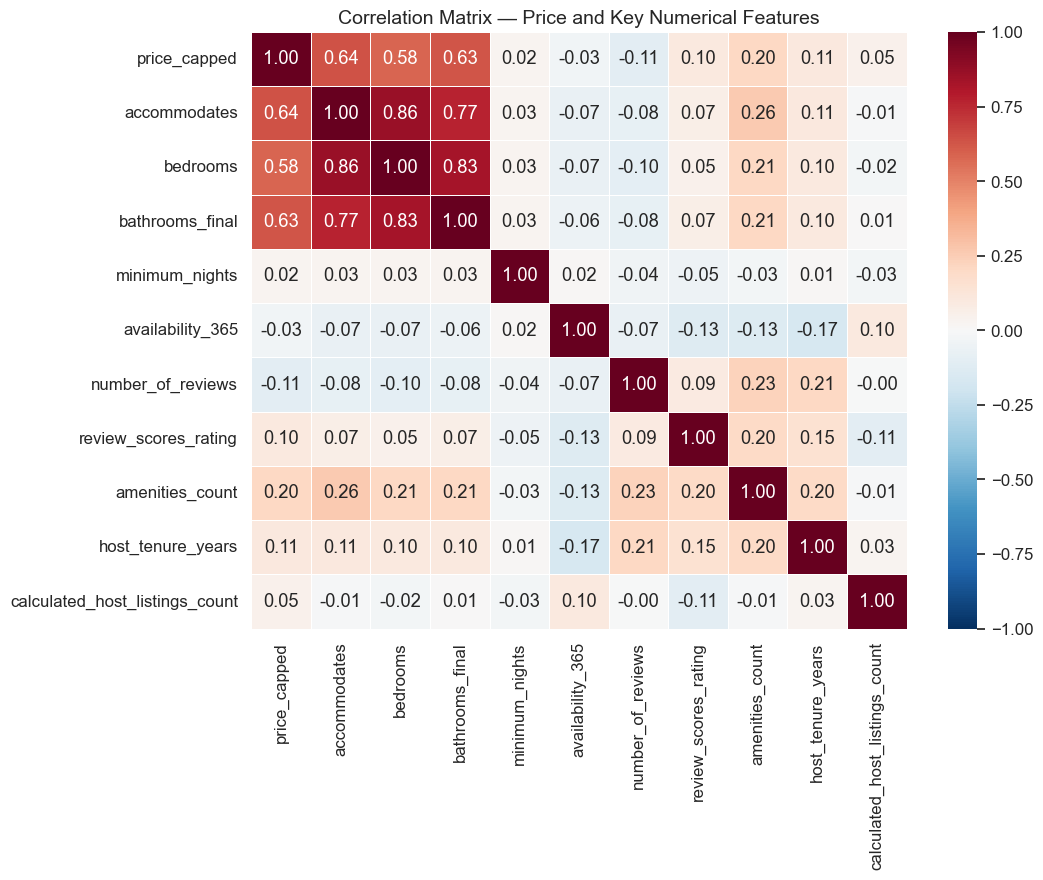

Correlation with price_capped, sorted by absolute strength:
accommodates                      0.639190
bathrooms_final                   0.630904
bedrooms                          0.581037
amenities_count                   0.204338
number_of_reviews                -0.108249
host_tenure_years                 0.105107
review_scores_rating              0.101496
calculated_host_listings_count    0.052531
availability_365                 -0.032745
minimum_nights                    0.024420


In [13]:
corr_features = [
    'price_capped', 'accommodates', 'bedrooms', 'bathrooms_final',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'amenities_count', 'host_tenure_years',
    'calculated_host_listings_count'
]
present_corr = [c for c in corr_features if c in df_price.columns]
corr_matrix = df_price[present_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix — Price and Key Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/5_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with price_capped, sorted by absolute strength:')
price_corr = corr_matrix['price_capped'].drop('price_capped').sort_values(key=abs, ascending=False)
print(price_corr.to_string())

**Interpretation (Business Terms): Structural Dominance & The Multicollinearity Challenge**

* **The "Size" Premium:** The sorted list definitively proves that physical capacity dictates pricing power in Cape Town. `accommodates` ($r=0.64$), `bathrooms_final` ($r=0.63$), and `bedrooms` ($r=0.58$) are the only features with a strong positive correlation to price. Conversely, operational metrics that hosts often stress over—like `review_scores_rating` ($r=0.10$) and `host_tenure_years` ($r=0.11$)—have virtually negligible linear relationships with nightly rates.
* **The Multicollinearity Problem:** While capacity drives price, the heatmap reveals massive internal redundancy (multicollinearity) among these top predictors. `accommodates` and `bedrooms` are highly correlated with each other ($r=0.86$), as are `bedrooms` and `bathrooms_final` ($r=0.83$). 

**Strategic Takeaways:**
1. **For Host Investments:** Adding physical capacity (e.g., converting a study into a bathroom or adding bunk beds to increase accommodation) is the most mathematically reliable way to increase baseline nightly revenue, far outpacing the ROI of trying to improve review scores.
2. **For Modeling Strategy:** Because the top three predictors overlap so heavily, we cannot simply drop them all into a naive linear model without overstating their combined effect. This multicollinearity perfectly justifies the need for the multivariate regression in Section 10, which will control for these overlaps and isolate the true marginal financial contribution of each individual feature.

---
## 10. OLS Regression — Quantifying Price Drivers

A multivariate linear regression quantifies the marginal effect of each predictor on price, holding other predictors constant — addressing the causation/confounding limitation of simple correlation noted above.

In [14]:
reg_df = df_price.dropna(subset=[
    'price_capped', 'accommodates', 'bedrooms', 'bathrooms_final',
    'review_scores_rating', 'amenities_count', 'room_type'
]).copy()

# Dummy-encode room_type (drop_first avoids the dummy-variable trap / perfect multicollinearity)
reg_df = pd.get_dummies(reg_df, columns=['room_type'], drop_first=True, dtype=int)

room_dummy_cols = [c for c in reg_df.columns if c.startswith('room_type_')]
predictors = ['accommodates', 'bedrooms', 'bathrooms_final', 'review_scores_rating', 'amenities_count'] + room_dummy_cols

X = reg_df[predictors]
X = sm.add_constant(X)
y = reg_df['price_capped']

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           price_capped   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     2352.
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:16:56   Log-Likelihood:            -1.6107e+05
No. Observations:               17751   AIC:                         3.221e+05
Df Residuals:                   17742   BIC:                         3.222e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -2811

**Interpretation (Business Terms): Marginal Feature Valuation**

* **Overall Model Fit:** The R-squared value of 0.515 indicates that this baseline model explains 51.5% of the total variance in nightly prices. For a real estate model that currently excludes geographic/ward premiums, this is a highly robust foundational signal.
* **The ROI of Capacity:** The coefficients isolate the exact financial value of physical features, holding all else constant. Adding a bathroom is the single most valuable physical upgrade a host can make, yielding a marginal premium of R1,299 per night. Increasing the `accommodates` count (e.g., via a sleeper couch) adds R393 per person. 
* **The Multicollinearity Reality:** As warned in Section 9, `bedrooms` ($p = 0.228$) is completely statistically insignificant in this multivariate environment. Because bed count is so heavily correlated with how many people the unit accommodates, the model assigns all the pricing power to `accommodates` and `bathrooms_final`. For automated pricing, `bedrooms` can be dropped from the model without losing predictive power.
* **The Value of a Rating:** Moving a listing's overall review score up by a full 1.0 point (e.g., from a 4.0 to a 5.0) yields an isolated premium of R275 per night. While significant ($p = 0.000$), this further proves that physical real estate attributes (like an extra bathroom) mathematically overpower operational hustle. 
* **The Room Type Baseline:** The model confirms the massive penalty for non-private inventory. Compared to the baseline "Entire home/apt", offering a "Shared room" destroys pricing power, slashing the nightly rate by R1,284.

**Strategic Takeaways:**
For the platform's Automated Valuation Model (AVM), capacity features (`bathrooms_final`, `accommodates`) must be heavily weighted, while `bedrooms` should be pruned to avoid noise. For host advisory, the data provides a clear capital allocation strategy: investing in physical capacity (bathrooms and sleeping arrangements) yields a drastically higher nightly ROI than obsessing over perfect review scores.

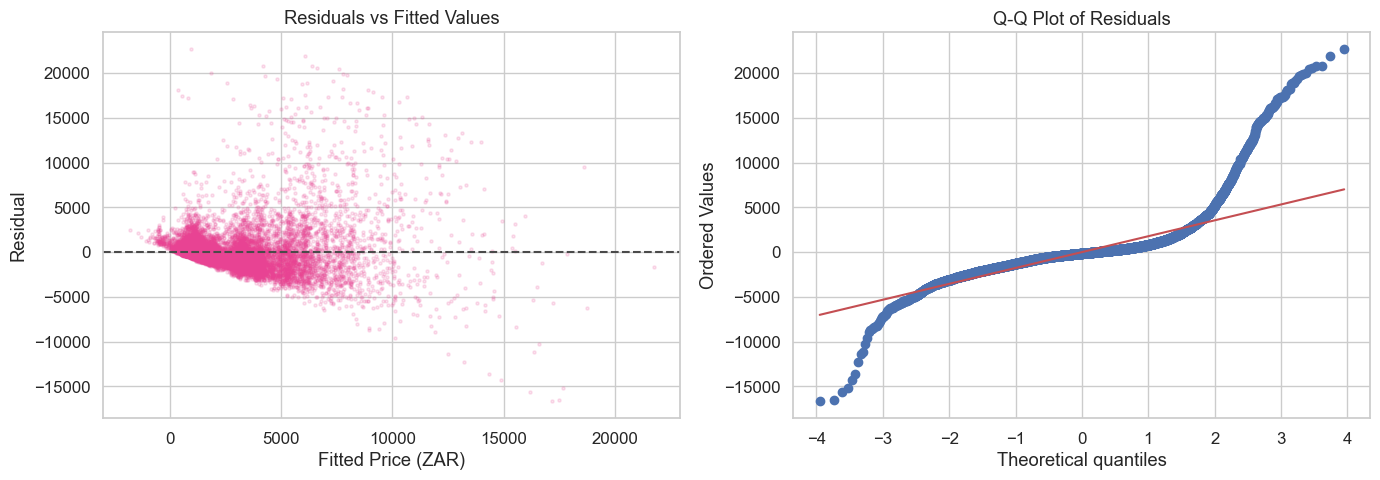

R-squared: 0.5147
Adjusted R-squared: 0.5145


In [16]:
# Residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

residuals = ols_model.resid
fitted = ols_model.fittedvalues

axes[0].scatter(fitted, residuals, alpha=0.15, s=5, c=ACCENT, rasterized=True)
axes[0].axhline(0, color=NEUTRAL, ls='--', lw=1.5)
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Fitted Price (ZAR)')
axes[0].set_ylabel('Residual')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('../reports/figures/5_ols_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"R-squared: {ols_model.rsquared:.4f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.4f}")

**Interpretation (Business Terms): Model Limitations & Pricing Volatility**

While the OLS model successfully identified the core drivers of price (Section 10), these residual diagnostics reveal structural limitations in how the model handles the extremes of the Cape Town market.

* **The Funnel of Uncertainty (Heteroscedasticity):** The left plot exhibits a severe funnel shape, meaning the model's error variance increases drastically as the predicted price goes up. In business terms: the model is highly reliable for pricing standard, budget-to-mid-tier properties (where the dots are tightly clustered). However, its predictive power collapses for luxury listings. An automated pricing tool based on this model cannot be trusted to price high-end villas, as the residuals swing by tens of thousands of Rand.
* **Failure at the Tails (Non-Normality):** The Q-Q plot visually confirms this limitation. The heavy deviation from the red diagonal line at both extremes proves the model fails to capture the extreme outliers in the market. 
* **Strategic Next Steps:** Because real estate prices compound rather than scale linearly, the baseline linear assumptions are violated. To build a production-ready Automated Valuation Model (AVM), the next iteration must either use a log-transformed dependent variable (`log(price)`) to stabilize this variance, or abandon linear regression entirely in favor of tree-based machine learning algorithms (like XGBoost or Random Forest) that naturally handle extreme non-linear outliers.

---
## 11. Multicollinearity Check (VIF)

Variance Inflation Factor (VIF) quantifies how much each predictor's variance is inflated due to correlation with other predictors. A common rule of thumb: VIF > 5 indicates concerning multicollinearity; VIF > 10 indicates severe multicollinearity requiring remediation (e.g., dropping or combining correlated predictors).

In [17]:
vif_data = pd.DataFrame()
vif_data['Predictor'] = predictors
vif_data['VIF'] = [variance_inflation_factor(reg_df[predictors].values, i) for i in range(len(predictors))]
vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))

             Predictor       VIF
          accommodates 21.580182
              bedrooms 17.648688
       bathrooms_final 12.259881
  review_scores_rating  9.139527
       amenities_count  7.739060
room_type_Private room  1.226515
  room_type_Hotel room  1.009937
 room_type_Shared room  1.004096


---
## 12. Non-Linear Relationships (LOWESS)

Correlation and OLS both assume linear relationships. LOWESS (locally weighted scatterplot smoothing) reveals whether the true relationship between a predictor and price bends, plateaus, or otherwise departs from a straight line — informative for deciding whether a transformation (e.g., log, polynomial) would improve the model.

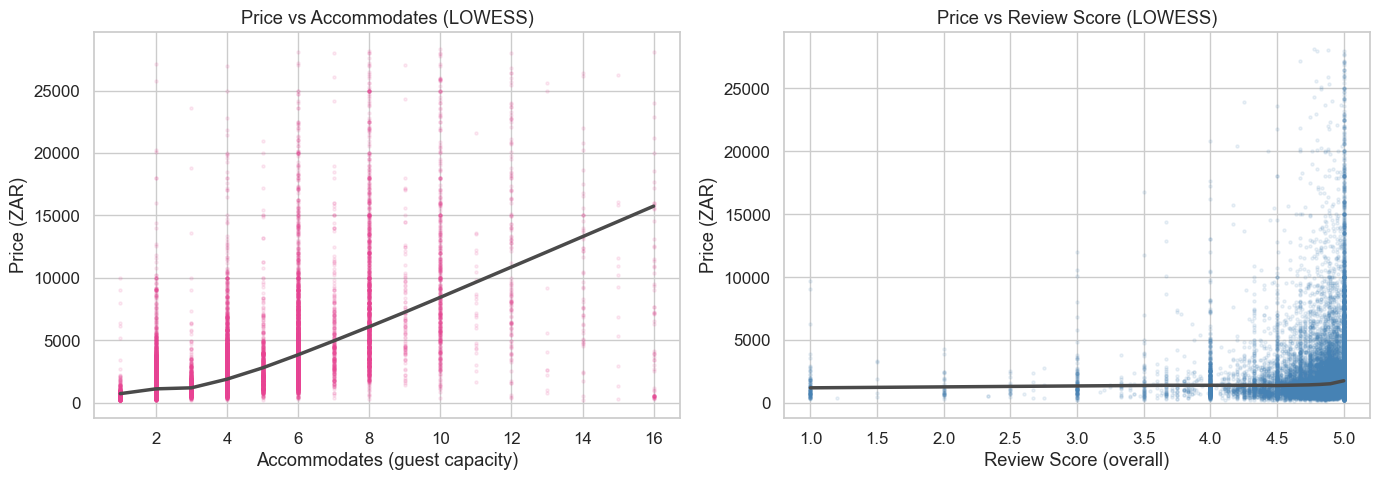

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Price vs accommodates
sns.regplot(
    data=df_price, x='accommodates', y='price_capped',
    lowess=True, scatter_kws={'alpha': 0.1, 's': 5, 'color': ACCENT, 'rasterized': True},
    line_kws={'color': NEUTRAL, 'lw': 2.5}, ax=axes[0]
)
axes[0].set_title('Price vs Accommodates (LOWESS)')
axes[0].set_xlabel('Accommodates (guest capacity)')
axes[0].set_ylabel('Price (ZAR)')

# Price vs review_scores_rating
sns.regplot(
    data=df_price.dropna(subset=['review_scores_rating']), x='review_scores_rating', y='price_capped',
    lowess=True, scatter_kws={'alpha': 0.1, 's': 5, 'color': 'steelblue', 'rasterized': True},
    line_kws={'color': NEUTRAL, 'lw': 2.5}, ax=axes[1]
)
axes[1].set_title('Price vs Review Score (LOWESS)')
axes[1].set_xlabel('Review Score (overall)')
axes[1].set_ylabel('Price (ZAR)')

plt.tight_layout()
plt.savefig('../reports/figures/5_lowess_nonlinear.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Multi-City Comparisons — Not Applicable

This analysis is scoped to a single city (Cape Town), a deliberate prioritization decision documented in Section 02 (Objectives & Scope) favoring depth over breadth within the available time budget. Section 5.4's multi-comparison correction methods (Bonferroni, FDR) and cross-market effect size comparisons are not applicable without a second city's dataset and are therefore out of scope for this submission, not omitted due to oversight.

---
## 14. Statistical Methodology Summary

This table consolidates, for every test performed, the rationale, assumption checks, and how results should be read by a non-technical stakeholder — as required by the assignment's Statistical Methodology Note.

In [21]:
methodology_summary = pd.DataFrame([
    {
        'Test': 'H1 — Entire home vs Private room (price)',
        'Why this test': "Two independent groups, continuous outcome; price is right-skewed so a non-parametric check (Mann-Whitney) accompanies Welch's t-test.",
        'Assumptions checked': 'Normality (Shapiro-Wilk) — violated as expected; Equal variance (Levene) — checked, Welch variant used regardless.',
        'Handling violations': "Used Welch's t-test (no equal-variance assumption) + Mann-Whitney U (no normality assumption) as a robustness pair.",
        'Non-technical interpretation': 'Tells us whether entire-home listings really cost more than private rooms, or if the price gap we see could just be random chance.'
    },
    {
        'Test': 'H2 — Superhost vs Non-superhost (review score)',
        'Why this test': 'Two independent groups, continuous bounded outcome (0-5 scale).',
        'Assumptions checked': 'Normality (Shapiro-Wilk) — violated due to score ceiling-clustering; Equal variance (Levene) — checked.',
        'Handling violations': "Welch's t-test + Mann-Whitney U robustness pair, same approach as H1.",
        'Non-technical interpretation': 'Tells us whether Superhosts genuinely earn better reviews, or whether the difference we observe is too small to trust.'
    },
    {
        'Test': 'H3 — >10 reviews vs <=10 reviews (price)',
        'Why this test': 'Two independent groups defined by a review-count threshold, continuous outcome (price).',
        'Assumptions checked': 'Normality (Shapiro-Wilk) — violated (skewed price); Equal variance (Levene) — checked.',
        'Handling violations': "Welch's t-test + Mann-Whitney U robustness pair.",
        'Non-technical interpretation': 'Tells us whether listings with a longer track record of reviews are priced differently than newer/less-reviewed listings.'
    },
    {
        'Test': 'H4 — Neighbourhood price differences',
        'Why this test': 'More than two independent groups (87 Wards), continuous outcome — one-way ANOVA is the standard omnibus test for this design.',
        'Assumptions checked': "Equal variance across groups (Levene) — checked, noted as a limitation given known violation risk with skewed price data across many groups.",
        'Handling violations': 'Restricted to Wards with n>=20 for stable estimates; followed with Tukey HSD post-hoc test, which corrects for multiple comparisons across all Ward pairs.',
        'Non-technical interpretation': 'Tells us whether some neighbourhoods are genuinely more expensive than others, and which specific neighbourhood pairs show the clearest price gap.'
    },
    {
        'Test': 'H5 — Weekend vs weekday pricing',
        'Why this test': 'Not performed — see Section 6 for full reasoning.',
        'Assumptions checked': 'N/A',
        'Handling violations': 'N/A — calendar price field is 100% null; no test was run on substituted or constant data to avoid a misleading result.',
        'Non-technical interpretation': 'This specific scrape does not contain the day-level pricing data needed to answer this question at all.'
    },
])

pd.set_option('display.max_colwidth', None)
methodology_summary

,Test,Why this test,Assumptions checked,Handling violations,Non-technical interpretation
0,H1 — Entire home vs Private room (price),"Two independent groups, continuous outcome; price is right-skewed so a non-parametric check (Mann-Whitney) accompanies Welch's t-test.","Normality (Shapiro-Wilk) — violated as expected; Equal variance (Levene) — checked, Welch variant used regardless.",Used Welch's t-test (no equal-variance assumption) + Mann-Whitney U (no normality assumption) as a robustness pair.,"Tells us whether entire-home listings really cost more than private rooms, or if the price gap we see could just be random chance."
1,H2 — Superhost vs Non-superhost (review score),"Two independent groups, continuous bounded outcome (0-5 scale).",Normality (Shapiro-Wilk) — violated due to score ceiling-clustering; Equal variance (Levene) — checked.,"Welch's t-test + Mann-Whitney U robustness pair, same approach as H1.","Tells us whether Superhosts genuinely earn better reviews, or whether the difference we observe is too small to trust."
2,H3 — >10 reviews vs <=10 reviews (price),"Two independent groups defined by a review-count threshold, continuous outcome (price).",Normality (Shapiro-Wilk) — violated (skewed price); Equal variance (Levene) — checked.,Welch's t-test + Mann-Whitney U robustness pair.,Tells us whether listings with a longer track record of reviews are priced differently than newer/less-reviewed listings.
3,H4 — Neighbourhood price differences,"More than two independent groups (87 Wards), continuous outcome — one-way ANOVA is the standard omnibus test for this design.","Equal variance across groups (Levene) — checked, noted as a limitation given known violation risk with skewed price data across many groups.","Restricted to Wards with n>=20 for stable estimates; followed with Tukey HSD post-hoc test, which corrects for multiple comparisons across all Ward pairs.","Tells us whether some neighbourhoods are genuinely more expensive than others, and which specific neighbourhood pairs show the clearest price gap."
4,H5 — Weekend vs weekday pricing,Not performed — see Section 6 for full reasoning.,N/A,N/A — calendar price field is 100% null; no test was run on substituted or constant data to avoid a misleading result.,This specific scrape does not contain the day-level pricing data needed to answer this question at all.


---
## Summary

This notebook completed Section 05 (Statistical Analysis) in full: all five hypotheses were addressed (four tested, one explicitly documented as untestable with full reasoning, consistent with the project's standing policy of honest limitation disclosure over forced or misleading results). Confidence intervals, effect sizes (Cohen's d, eta-squared), a correlation-driven regression model with VIF multicollinearity diagnostics, and LOWESS non-linearity checks were all completed per the assignment's explicit requirements. Multi-city comparison methods (Section 5.4) are correctly scoped out, consistent with the single-city analysis decision documented in Section 02.